<a href="https://colab.research.google.com/github/maazali04/deep-learning-from-scratch/blob/main/02_multilayer_perceptron_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Layer Perceptron (MLP)

This notebook builds directly on single neurons by stacking hidden layers to solve non-linear problems, moving step-by-step from raw mathematical derivations to custom NumPy code and framework benchmarking.

## Why need MLP?

A single neuron without a hidden layer can only learn linearly separable boundaries (a straight line in 2D space).

If we plot the truth table of the AND or OR gates, we can draw a single straight line that perfectly separates the 0 outputs from the 1 outputs. However, the XOR gate outputs 1 only when the inputs are different.

Because the opposite corners share the same class, no single straight line can separate them. A single neuron will always fail because it can only define a linear decision boundary ($w_1x_1 + w_2x_2 + b = 0$)

To solve XOR, we must introduce at least one hidden layer with a non-linear activation function (like ReLU or Sigmoid). This warps the input space, making the data points linearly separable by the final output layer.







## Structure of MLP

In our case we need a 2-2-1 MLP:

- Input Layer: Contains two inputs $(x_{1}$ and $x_{2})$ that pass raw features forward without performing mathematical operations.
- Hidden Layer: Contains two neurons that compute independent weighted sums $(z_{1}$and$z_{2})$ plus their respective biases $(b_{11}$ and $b_{12})$.

- Hidden Activation Function: Squeezes the results of those hidden neurons through individual sigmoid operations to generate non-linear activations $(a_{1}$ and $a_{2})$.

- Output Layer: Takes the hidden layer activations, computes a single combined weighted sum $(z_{out})$, and passes it through a final sigmoid function to produce the prediction ($\hat {y}$).

<p align="center">
  <img src="https://raw.githubusercontent.com/maazali04/deep-learning-from-scratch/main/images/2-2-1-mlp.svg" width="500" alt="2-2-1 mlp Diagram">
</p>

## Mathematically

### Forward Pass

1. Input Layer
  
  The input vector contains your two raw feature variables:
  $$\mathbf{X}=\left[\begin{matrix}x_{1}\\ x_{2}\end{matrix}\right]$$

2. Hidden Layer (Linear Combination)
  Each of the two hidden neurons calculates its net weighted sum $(z)$ by multiplying the inputs by their corresponding weights and adding a bias:
  - Neuron 1:$$z_{11}=w_{11}^{(1)}x_{1}+w_{21}^{(1)}x_{2}+b_{11}$$
  - Neuron 2:$$z_{12}=w_{12}^{(1)}x_{1}+w_{22}^{(1)}x_{2}+b_{12}$$

3. Hidden Activation Function
  The net inputs ($z_{11}, z_{12}$) are passed separately through the non-linear Sigmoid activation function $(\sigma )$ to produce the hidden activations $(a_1, a_2)$:
  
  $$\sigma (z)=\frac{1}{1+e^{-z}}$$
  
  - Activation 1:
  $$a_{11}=\sigma (z_{11})=\frac{1}{1+e^{-z_{11}}}$$
  
  - Activation 2:
  $$a_{12}=\sigma (z_{12})=\frac{1}{1+e^{-z_{12}}}$$


4. Output Layer
  The single output neuron treats $a_{11}$ and $a_{12}$ as its inputs. It calculates its net input $(z_{21})$, then passes it through a final Sigmoid function to generate the prediction $(\hat {y})$:
  - Output Weighted Sum:
  $$z_{21}=w_{11}^{(2)}a_{11}+w_{21}^{(2)}a_{12}+b_{21}$$

  - Final Prediction:
  $$\hat{y}=a_{21}=\sigma (z_{21})=\frac{1}{1+e^{-z_{21}}}$$

### Loss Evaluation

Since XOR is a binary classification problem (the output is either 0 or 1), we use the Binary Cross-Entropy (BCE) Loss function.

$$L=-\Big[y\log (\hat {y})+(1-y)\log (1-\hat {y})\Big]$$

### Backward Pass
It consists of the following steps:

- Loss Equation:
  $$L = - [y \ln(\hat{y}) + (1 - y) \ln(1 - \hat{y})]$$

- Step 1: Derivative of Loss w.r.t. Output Prediction ($\frac{\partial L}{\partial \hat{y}}$)

  $$\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$$

- Step 2: Derivative of Loss w.r.t. Output Activation ($\frac{\partial L}{\partial a_{21}}$)

  Since $a_{21} = \hat{y}$, this step is identical to Step 1:
  $$\frac{\partial L}{\partial a_{21}} = \frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$$
  
- Step 3: Derivative of Loss w.r.t. Output Pre-Activation ($\frac{\partial L}{\partial z_{21}}$)
  
  Apply the chain rule through the output Sigmoid activation ($a_{21} = \sigma(z_{21})$):
  $$\frac{\partial L}{\partial z_{21}} = \frac{\partial L}{\partial a_{21}} \cdot \frac{\partial a_{21}}{\partial z_{21}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})} \cdot a_{21}(1 - a_{21}) = \hat{y} - y$$
  
- Step 4: Derivative of Loss w.r.t. Output Layer Weights ($\frac{\partial L}{\partial w_{11}^{(2)}}, \frac{\partial L}{\partial w_{21}^{(2)}}$) and Bias ($\frac{\partial L}{\partial b_{21}}$)

  $$\frac{\partial L}{\partial w_{11}^{(2)}} = \frac{\partial L}{\partial z_{21}} \cdot \frac{\partial z_{21}}{\partial w_{11}^{(2)}} = (\hat{y} - y) a_{11}$$
  
  $$\frac{\partial L}{\partial w_{21}^{(2)}} = \frac{\partial L}{\partial z_{21}} \cdot \frac{\partial z_{21}}{\partial w_{21}^{(2)}} = (\hat{y} - y) a_{12}$$
  
  $$\frac{\partial L}{\partial b_{21}} = \frac{\partial L}{\partial z_{21}} \cdot \frac{\partial z_{21}}{\partial b_{21}} = (\hat{y} - y) \cdot 1 = \hat{y} - y$$
  
- Step 5: Derivative of Loss w.r.t. Hidden Activations ($\frac{\partial L}{\partial a_{11}}, \frac{\partial L}{\partial a_{12}}$)
  
  $$\frac{\partial L}{\partial a_{11}} = \frac{\partial L}{\partial z_{21}} \cdot \frac{\partial z_{21}}{\partial a_{11}} = (\hat{y} - y) w_{11}^{(2)}$$
  $$\frac{\partial L}{\partial a_{12}} = \frac{\partial L}{\partial z_{21}} \cdot \frac{\partial z_{21}}{\partial a_{12}} = (\hat{y} - y) w_{21}^{(2)}$$
  
- Step 6: Derivative of Loss w.r.t. Hidden Pre-Activations ($\frac{\partial L}{\partial z_{11}}, \frac{\partial L}{\partial z_{12}}$)
  $$\frac{\partial L}{\partial z_{11}} = \frac{\partial L}{\partial a_{11}} \cdot \frac{\partial a_{11}}{\partial z_{11}} = (\hat{y} - y) w_{11}^{(2)} \cdot a_{11}(1 - a_{11})$$
  $$\frac{\partial L}{\partial z_{12}} = \frac{\partial L}{\partial a_{12}} \cdot \frac{\partial a_{12}}{\partial z_{12}} = (\hat{y} - y) w_{21}^{(2)} \cdot a_{12}(1 - a_{12})$$
  
- Step 7: Derivative of Loss w.r.t. Hidden Layer Weights ($\frac{\partial L}{\partial w_{11}^{(1)}}, \frac{\partial L}{\partial w_{12}^{(1)}}, \frac{\partial L}{\partial w_{21}^{(1)}}, \frac{\partial L}{\partial w_{22}^{(1)}}$) and Biases ($\frac{\partial L}{\partial b_{11}}, \frac{\partial L}{\partial b_{12}}$)

  - Hidden Neuron 1 Parameters:
     $$\frac{\partial L}{\partial w_{11}^{(1)}} = \frac{\partial L}{\partial z_{11}} \cdot \frac{\partial z_{11}}{\partial w_{11}^{(1)}} = (\hat{y} - y) w_{11}^{(2)} a_{11}(1 - a_{11}) x_1$$
     $$\frac{\partial L}{\partial w_{12}^{(1)}} = \frac{\partial L}{\partial z_{11}} \cdot \frac{\partial z_{11}}{\partial w_{12}^{(1)}} = (\hat{y} - y) w_{11}^{(2)} a_{11}(1 - a_{11}) x_2$$
     $$\frac{\partial L}{\partial b_{11}} = \frac{\partial L}{\partial z_{11}} \cdot \frac{\partial z_{11}}{\partial b_{11}} = (\hat{y} - y) w_{11}^{(2)} a_{11}(1 - a_{11})$$
     
    - Hidden Neuron 2 Parameters:
      $$\frac{\partial L}{\partial w_{21}^{(1)}} = \frac{\partial L}{\partial z_{12}} \cdot \frac{\partial z_{12}}{\partial w_{21}^{(1)}} = (\hat{y} - y) w_{21}^{(2)} a_{12}(1 - a_{12}) x_1$$
      $$\frac{\partial L}{\partial w_{22}^{(1)}} = \frac{\partial L}{\partial z_{12}} \cdot \frac{\partial z_{12}}{\partial w_{22}^{(1)}} = (\hat{y} - y) w_{21}^{(2)} a_{12}(1 - a_{12}) x_2$$
      $$\frac{\partial L}{\partial b_{12}} = \frac{\partial L}{\partial z_{12}} \cdot \frac{\partial z_{12}}{\partial b_{12}} = (\hat{y} - y) w_{21}^{(2)} a_{12}(1 - a_{12})$$

### Optimization Step

The optimizer (like SGD or Adam) takes the gradients computed in Step 3 and modifies the actual weights and biases in memory.

- Output Layer Parameters:
  $$w_{11}^{(2)} \leftarrow w_{11}^{(2)} - \eta \cdot \frac{\partial L}{\partial w_{11}^{(2)}}$$
  $$w_{21}^{(2)} \leftarrow w_{21}^{(2)} - \eta \cdot \frac{\partial L}{\partial w_{21}^{(2)}}$$
  $$b_{21} \leftarrow b_{21} - \eta \cdot \frac{\partial L}{\partial b_{21}}$$
  
- Hidden Layer Parameters:
  $$w_{11}^{(1)} \leftarrow w_{11}^{(1)} - \eta \cdot \frac{\partial L}{\partial w_{11}^{(1)}}, \quad w_{12}^{(1)} \leftarrow w_{12}^{(1)} - \eta \cdot \frac{\partial L}{\partial w_{12}^{(1)}}, \quad b_{11} \leftarrow b_{11} - \eta \cdot \frac{\partial L}{\partial b_{11}}$$
  $$w_{21}^{(1)} \leftarrow w_{21}^{(1)} - \eta \cdot \frac{\partial L}{\partial w_{21}^{(1)}}, \quad w_{22}^{(1)} \leftarrow w_{22}^{(1)} - \eta \cdot \frac{\partial L}{\partial w_{22}^{(1)}}, \quad b_{12} \leftarrow b_{12} - \eta \cdot \frac{\partial L}{\partial b_{12}}$$

## Python Implementation

### Custom Numpy

In [ ]:
import numpy as np

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1.0 - a)

# XOR Dataset
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])
y = np.array([[0.0], [1.0], [1.0], [0.0]])

# Parameter Initialization
np.random.seed(42)

# Layer 1 Weights and Biases
w11_1 = np.random.randn()
w12_1 = np.random.randn()
b11 = 0.0

w21_1 = np.random.randn()
w22_1 = np.random.randn()
b12 = 0.0

# Layer 2 Weights and Bias
w11_2 = np.random.randn()
w21_2 = np.random.randn()
b21 = 0.0

learning_rate = 0.5
epochs = 10000

print("--- Starting Training Loop for 2-2-1 MLP ---")

for epoch in range(epochs):
    epoch_loss = 0.0

    # Gradient Accumulators
    dL_dw11_1, dL_dw12_1, dL_db11 = 0.0, 0.0, 0.0
    dL_dw21_1, dL_dw22_1, dL_db12 = 0.0, 0.0, 0.0
    dL_dw11_2, dL_dw21_2, dL_db21 = 0.0, 0.0, 0.0

    m = X.shape[0]

    for i in range(m):
        x1, x2 = X[i, 0], X[i, 1]
        target = y[i, 0]

        # ==========================================
        # 1. FORWARD PASS
        # ==========================================
        # Hidden Neuron 1
        z11 = w11_1 * x1 + w12_1 * x2 + b11
        a11 = sigmoid(z11)

        # Hidden Neuron 2
        z12 = w21_1 * x1 + w22_1 * x2 + b12
        a12 = sigmoid(z12)

        # Output Neuron
        z21 = w11_2 * a11 + w21_2 * a12 + b21
        a21 = sigmoid(z21)
        y_hat = a21

        # ==========================================
        # 2. LOSS EVALUATION (Binary Cross-Entropy)
        # ==========================================
        loss = -(target * np.log(y_hat + 1e-15) + (1.0 - target) * np.log(1.0 - y_hat + 1e-15))
        epoch_loss += loss

        # ==========================================
        # 3. BACKWARD PASS
        # ==========================================
        # Step 1: Loss w.r.t Output Prediction
        dL_dyhat = (y_hat - target) / ((y_hat * (1.0 - y_hat)) + 1e-15)

        # Step 2: Loss w.r.t Output Activation
        dL_da21 = dL_dyhat

        # Step 3: Loss w.r.t Output Pre-Activation
        dL_dz21 = y_hat - target

        # Step 4: Loss w.r.t Output Parameters
        dL_dw11_2 += dL_dz21 * a11
        dL_dw21_2 += dL_dz21 * a12
        dL_db21 += dL_dz21

        # Step 5: Loss w.r.t Hidden Activations
        dL_da11 = dL_dz21 * w11_2
        dL_da12 = dL_dz21 * w21_2

        # Step 6: Loss w.r.t Hidden Pre-Activations
        dL_dz11 = dL_da11 * sigmoid_derivative(a11)
        dL_dz12 = dL_da12 * sigmoid_derivative(a12)

        # Step 7: Loss w.r.t Hidden Layer Parameters
        dL_dw11_1 += dL_dz11 * x1
        dL_dw12_1 += dL_dz11 * x2
        dL_db11 += dL_dz11

        dL_dw21_1 += dL_dz12 * x1
        dL_dw22_1 += dL_dz12 * x2
        dL_db12 += dL_dz12

    # Average gradients over batch
    dL_dw11_2 /= m
    dL_dw21_2 /= m
    dL_db21 /= m

    dL_dw11_1 /= m
    dL_dw12_1 /= m
    dL_db11 /= m

    dL_dw21_1 /= m
    dL_dw22_1 /= m
    dL_db12 /= m

    # ==========================================
    # 4. OPTIMIZATION STEP
    # ==========================================
    w11_2 -= learning_rate * dL_dw11_2
    w21_2 -= learning_rate * dL_dw21_2
    b21 -= learning_rate * dL_db21

    w11_1 -= learning_rate * dL_dw11_1
    w12_1 -= learning_rate * dL_dw12_1
    b11 -= learning_rate * dL_db11

    w21_1 -= learning_rate * dL_dw21_1
    w22_1 -= learning_rate * dL_dw22_1
    b12 -= learning_rate * dL_db12

    if (epoch + 1) % 2000 == 0:
        print(f"Epoch {epoch+1:5d} | Loss: {epoch_loss / m:.6f}")

# --- Final Predictions ---
print("\n--- Predictions After Training ---")
for i in range(4):
    x1, x2 = X[i, 0], X[i, 1]
    z11 = w11_1 * x1 + w12_1 * x2 + b11
    a11 = sigmoid(z11)
    z12 = w21_1 * x1 + w22_1 * x2 + b12
    a12 = sigmoid(z12)
    z21 = w11_2 * a11 + w21_2 * a12 + b21
    y_hat = sigmoid(z21)
    print(f"Input: [{x1:.0f}, {x2:.0f}] -> Predicted: {y_hat:.4f} (Target: {y[i, 0]:.0f})")

--- Starting Training Loop for 2-2-1 MLP ---
Epoch  2000 | Loss: 0.016574
Epoch  4000 | Loss: 0.006107
Epoch  6000 | Loss: 0.003712
Epoch  8000 | Loss: 0.002659
Epoch 10000 | Loss: 0.002069

--- Predictions After Training ---
Input: [0, 0] -> Predicted: 0.0026 (Target: 0)
Input: [0, 1] -> Predicted: 0.9981 (Target: 1)
Input: [1, 0] -> Predicted: 0.9981 (Target: 1)
Input: [1, 1] -> Predicted: 0.0019 (Target: 0)


We have successfully built a 2-2-1 MLP that effectively solves the XOR problem.

### PyTorch

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Data Setup
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])
y = np.array([[0.0], [1.0], [1.0], [0.0]])

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# 2. Model Definition (2-2-1 MLP)
xor_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.Sigmoid(),
    nn.Linear(2, 1),
    nn.Sigmoid()
)

epochs = 10000
loss_fn = nn.BCELoss()
optimizer = optim.SGD(xor_model.parameters(), lr=0.5)

print("--- PyTorch Training Loop ---")
for epoch in range(epochs):
    # Step 1: Forward Pass
    y_pred = xor_model(X)

    # Step 2: Loss Evaluation
    loss = loss_fn(y_pred, y)

    # Step 3: Backward Pass
    optimizer.zero_grad()
    loss.backward()

    # Step 4: Optimization Step
    optimizer.step()

    if (epoch + 1) % 2000 == 0:
        print(f"Epoch {epoch+1:5d} | Loss: {loss.item():.6f}")

# 3. Final Model Evaluation
xor_model.eval()
with torch.no_grad():
    predictions = xor_model(X)
    print("\n--- Final Predictions ---")
    for i in range(len(X)):
        x1, x2 = X[i][0].item(), X[i][1].item()
        pred = predictions[i].item()
        target = y[i].item()
        print(f"Input: [{x1:.0f}, {x2:.0f}] -> Predicted: {pred:.4f} (Target: {target:.0f})")

--- PyTorch Training Loop ---
Epoch  2000 | Loss: 0.020829
Epoch  4000 | Loss: 0.006569
Epoch  6000 | Loss: 0.003863
Epoch  8000 | Loss: 0.002730
Epoch 10000 | Loss: 0.002108

--- Final Predictions ---
Input: [0, 0] -> Predicted: 0.0020 (Target: 0)
Input: [0, 1] -> Predicted: 0.9981 (Target: 1)
Input: [1, 0] -> Predicted: 0.9972 (Target: 1)
Input: [1, 1] -> Predicted: 0.0018 (Target: 0)


<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1577/3037063842.py:21: SyntaxWarning: invalid escape sequence '\h'
  cbar.set_label("Predicted Probability ($\hat{y}$)")


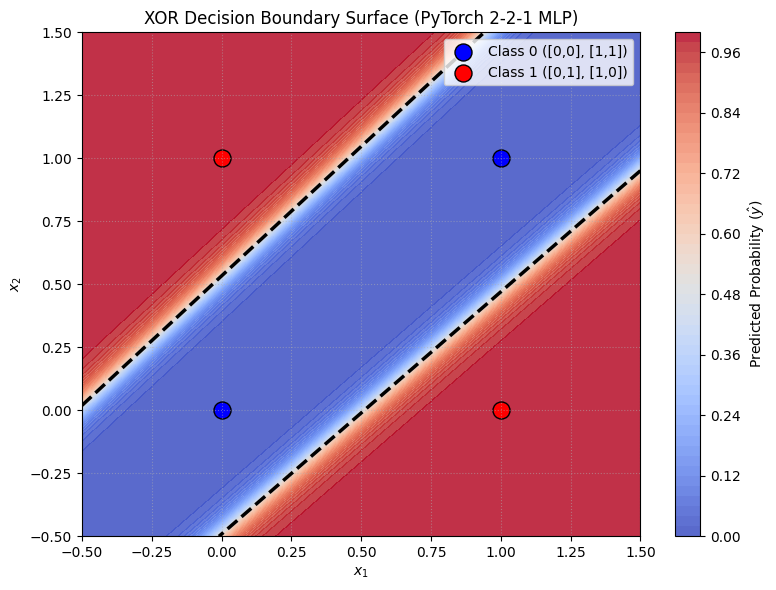

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create evaluation grid over input space
x1_range = np.linspace(-0.5, 1.5, 300)
x2_range = np.linspace(-0.5, 1.5, 300)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid_tensor = torch.tensor(np.c_[xx1.ravel(), xx2.ravel()], dtype=torch.float32)

# 2. Forward pass grid through trained model
xor_model.eval()
with torch.no_grad():
    grid_preds = xor_model(grid_tensor).reshape(xx1.shape).numpy()

# 3. Plot Decision Boundary & Data Points
plt.figure(figsize=(8, 6))

# Smooth probability landscape fill
contour = plt.contourf(xx1, xx2, grid_preds, levels=50, cmap="coolwarm", alpha=0.85)
cbar = plt.colorbar(contour)
cbar.set_label("Predicted Probability ($\hat{y}$)")

# Decision boundary line at threshold 0.5
plt.contour(xx1, xx2, grid_preds, levels=[0.5], colors="black", linewidths=2.5, linestyles="--")

# Scatter original XOR data points
X_np = X.numpy()
y_np = y.numpy().ravel()

plt.scatter(
    X_np[y_np == 0, 0], X_np[y_np == 0, 1],
    color="blue", s=150, edgecolor="k", label="Class 0 ([0,0], [1,1])"
)
plt.scatter(
    X_np[y_np == 1, 0], X_np[y_np == 1, 1],
    color="red", s=150, edgecolor="k", label="Class 1 ([0,1], [1,0])"
)

plt.title("XOR Decision Boundary Surface (PyTorch 2-2-1 MLP)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

# Generalizing MLPs: Layers, Neurons, and Hyperparameters

The 2-2-1 network was just a minimal toy example to manually derive backpropagation. In real-world deep learning, Multi-Layer Perceptrons are fully modular, giving you total freedom over the network's architecture and training dynamics:
- Network Depth (Hidden Layers): Stack as many hidden layers as needed ($L_1, L_2, \dots, L_k$) to build deeper hierarchical representations of your data.
- Network Width (Neuron Count): Increase the number of neurons per layer (e.g., $64 \to 128 \to 64$) to expand the model's capacity to learn complex patterns.
- Activation Functions: Swap Sigmoid for ReLU, LeakyReLU, Tanh, or GELU in hidden layers to prevent vanishing gradients and speed up convergence.
- Optimizers: Replace standard Stochastic Gradient Descent (SGD) with adaptive optimizers like Adam, RMSprop, or SGD with Momentum for faster, smoother gradient descent.
- Output Flexibility: Change the final activation and loss function based on the task—such as using Softmax with Categorical Cross-Entropy for multi-class classification, or no output activation with MSE for regression.

## General Diagram of MLP

<p align="center">
  <img src="https://raw.githubusercontent.com/maazali04/deep-learning-from-scratch/main/images/mlp.svg" width="500" alt="General MLP Diagram">
</p>

## Practical Experiments: Varying Network Depth, Width, Activations, and Optimizers



### Project 1

In [ ]:
from sklearn.datasets import make_circles
import pandas as pd
n_samples = 1000
X, y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values

circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


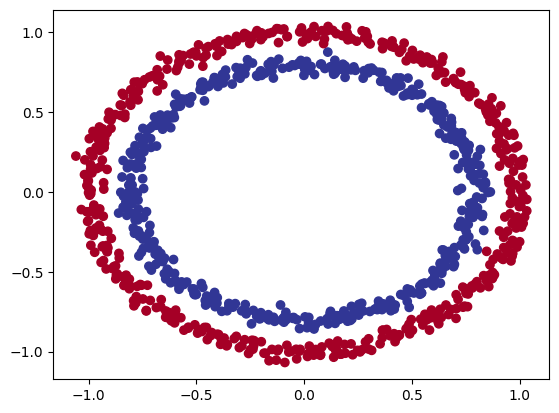

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);


In [ ]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
import torch
from sklearn.model_selection import train_test_split
from torch import nn


torch.manual_seed(42)
epochs = 1000

circle_model = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.Tanh(),
    nn.Linear(in_features=10, out_features=10),
    nn.Tanh(),
    nn.Linear(in_features=10, out_features=1),
    nn.Sigmoid()
)

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(circle_model.parameters(), lr=0.01)


for epoch in range(epochs):
    circle_model.train()
    y_preds = circle_model(X_train).squeeze()
    loss = loss_fn(y_preds, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    circle_model.eval()
    with torch.inference_mode():
        test_preds = circle_model(X_test).squeeze()
        test_loss = loss_fn(test_preds, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")



Epoch: 0 | Train Loss: 0.69331 | Test Loss: 0.69260
Epoch: 100 | Train Loss: 0.05224 | Test Loss: 0.07723
Epoch: 200 | Train Loss: 0.00721 | Test Loss: 0.01745
Epoch: 300 | Train Loss: 0.00348 | Test Loss: 0.01012
Epoch: 400 | Train Loss: 0.00217 | Test Loss: 0.00721
Epoch: 500 | Train Loss: 0.00149 | Test Loss: 0.00555
Epoch: 600 | Train Loss: 0.00105 | Test Loss: 0.00444
Epoch: 700 | Train Loss: 0.00077 | Test Loss: 0.00368
Epoch: 800 | Train Loss: 0.00062 | Test Loss: 0.00318
Epoch: 900 | Train Loss: 0.00050 | Test Loss: 0.00282


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_decision_boundary(model, X, y):
    model.eval()

    # Define plot bounds with padding
    x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
    y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)
    )

    grid_tensor = torch.tensor(
        np.column_stack((xx.ravel(), yy.ravel())), dtype=torch.float32
    )

    with torch.inference_mode():
        logits = model(grid_tensor)

    # Multi-Class vs. Binary output check
    if logits.shape[1] > 1:
        # Multi-class: Pick class index with the highest logit score
        preds = torch.softmax(logits, dim=1).argmax(dim=1)
    else:
        # Binary: Round probability threshold at 0.5
        preds = torch.round(torch.sigmoid(logits))

    # Reshape predictions back to grid dimensions
    preds = preds.reshape(xx.shape)

    # Plot decision boundary regions
    plt.contourf(xx, yy, preds.numpy(), cmap=plt.cm.RdYlBu, alpha=0.7)

    # Scatter actual data points
    X_np = X.numpy()
    y_np = y.numpy().ravel()
    plt.scatter(
        X_np[:, 0], X_np[:, 1], c=y_np, cmap=plt.cm.RdYlBu, edgecolors="k", s=40
    )

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.grid(True, linestyle=":", alpha=0.5)

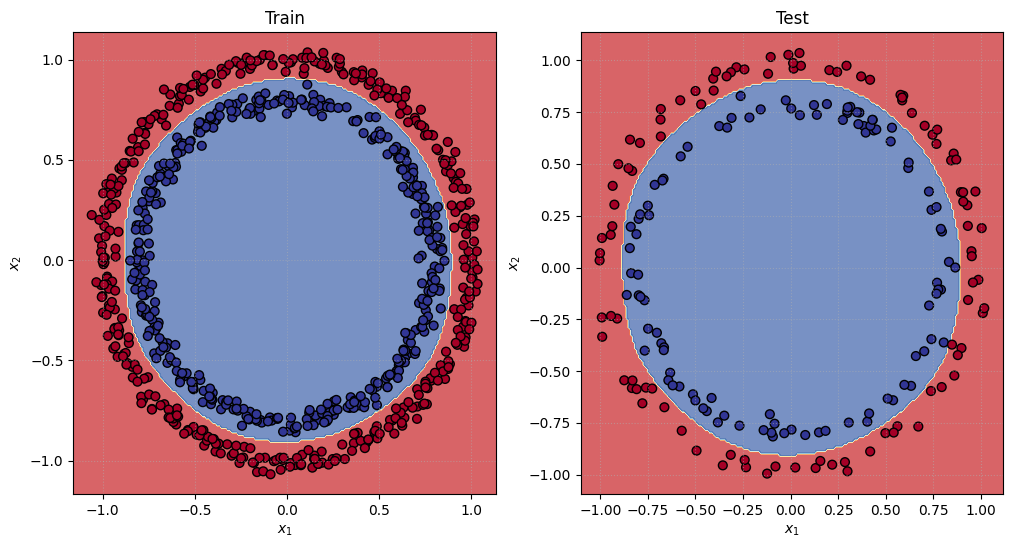

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(circle_model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(circle_model, X_test, y_test)

### Project 2

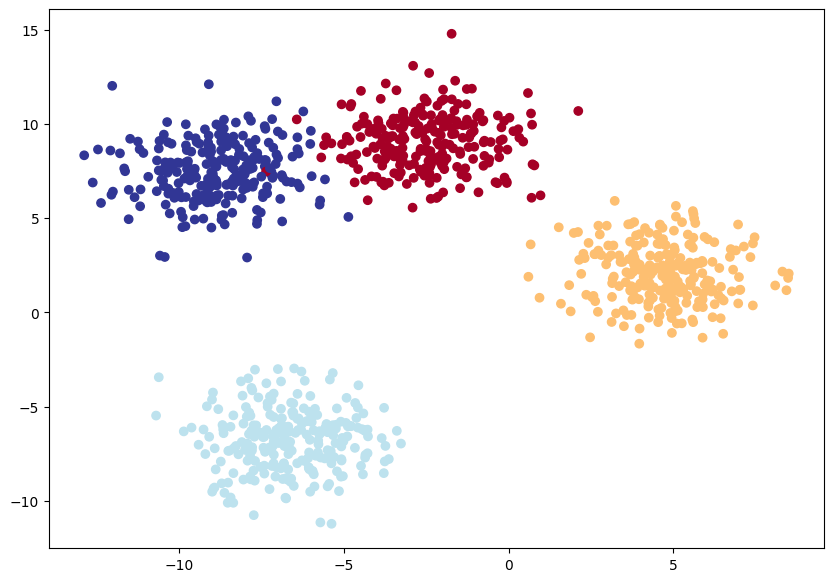

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=2,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=42
)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);


In [ ]:
bloob_model = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=4),
)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(bloob_model.parameters(), lr=0.01)


In [ ]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    bloob_model.train()

    y_preds = bloob_model(X_blob_train)
    loss = loss_fn(y_preds, y_blob_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    bloob_model.eval()
    with torch.inference_mode():
      test_pred = bloob_model(X_blob_test)
      test_loss = loss_fn(test_pred, y_blob_test)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} |Train Loss: {loss:.5f}| Test Loss: {test_loss:.5f}")

Epoch: 0 |Train Loss: 1.50867| Test Loss: 1.44383
Epoch: 10 |Train Loss: 1.11727| Test Loss: 1.10844
Epoch: 20 |Train Loss: 0.63816| Test Loss: 0.63257
Epoch: 30 |Train Loss: 0.16605| Test Loss: 0.14003
Epoch: 40 |Train Loss: 0.04621| Test Loss: 0.03916
Epoch: 50 |Train Loss: 0.03253| Test Loss: 0.02278
Epoch: 60 |Train Loss: 0.02883| Test Loss: 0.01975
Epoch: 70 |Train Loss: 0.02714| Test Loss: 0.01699
Epoch: 80 |Train Loss: 0.02622| Test Loss: 0.01584
Epoch: 90 |Train Loss: 0.02550| Test Loss: 0.01543


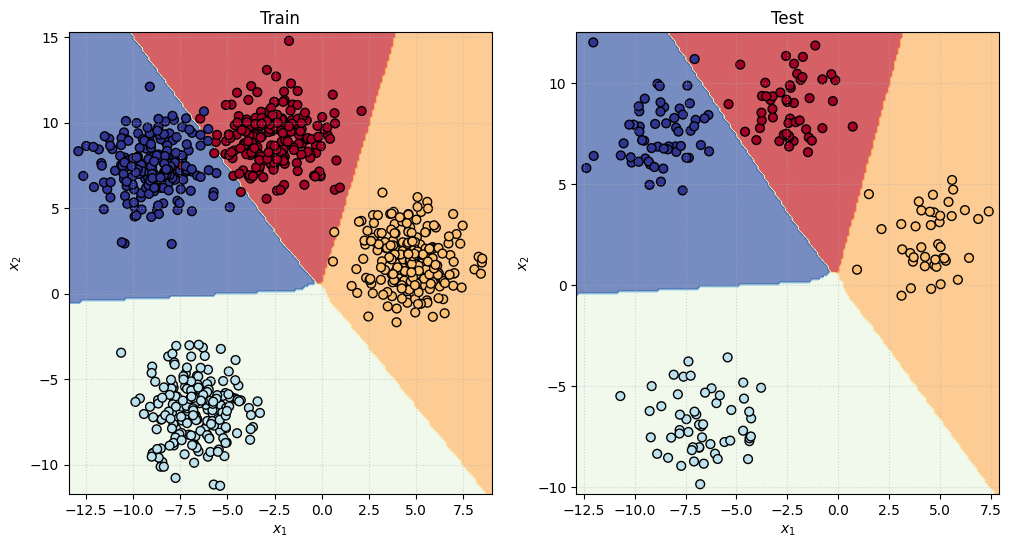

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(bloob_model, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(bloob_model, X_blob_test, y_blob_test)

### Project 3

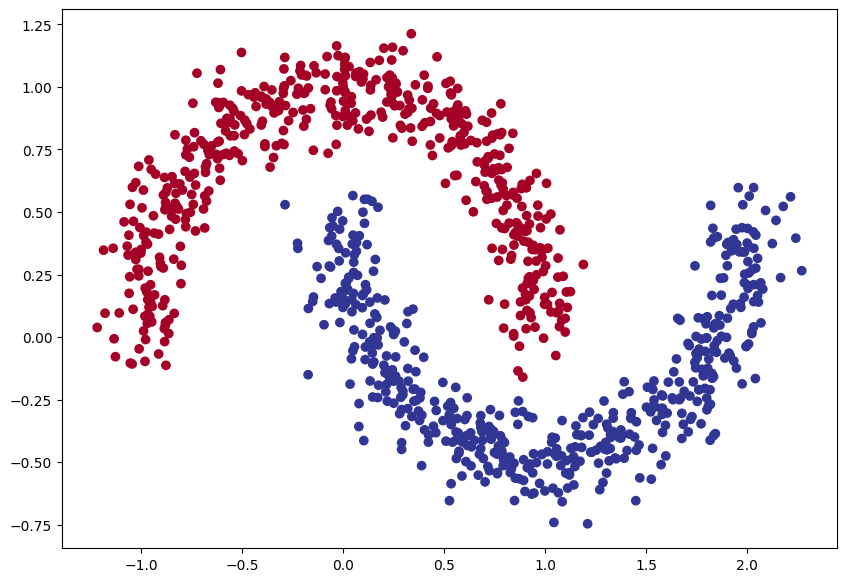

In [ ]:
import torch
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X_moons, y_moons = make_moons(
    n_samples=1000,
    noise=0.1,
    random_state=42,
)

X = torch.tensor(X_moons, dtype=torch.float32)
y = torch.tensor(y_moons, dtype=torch.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)


plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);


In [ ]:
model_moon = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.Tanh(),
    nn.Linear(in_features=10, out_features=10),
    nn.Tanh(),
    nn.Linear(in_features=10, out_features=1),
)

torch.manual_seed(42)
epochs = 1000
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_moon.parameters(), lr=0.1)

In [ ]:
for epoch in range(epochs):
    model_moon.train()

    y_logits = model_moon(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_moon.eval()
    with torch.inference_mode():
        test_logits = model_moon(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)


    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch} | Train Loss: {loss:.5f}| Test Loss: {test_loss:.5f}"
        )

Epoch: 0 | Train Loss: 0.71501| Test Loss: 0.56838
Epoch: 100 | Train Loss: 0.00084| Test Loss: 0.00034
Epoch: 200 | Train Loss: 0.00039| Test Loss: 0.00016
Epoch: 300 | Train Loss: 0.00020| Test Loss: 0.00008
Epoch: 400 | Train Loss: 0.00012| Test Loss: 0.00005
Epoch: 500 | Train Loss: 0.00008| Test Loss: 0.00004
Epoch: 600 | Train Loss: 0.00005| Test Loss: 0.00003
Epoch: 700 | Train Loss: 0.00004| Test Loss: 0.00002
Epoch: 800 | Train Loss: 0.00003| Test Loss: 0.00002
Epoch: 900 | Train Loss: 0.00002| Test Loss: 0.00001


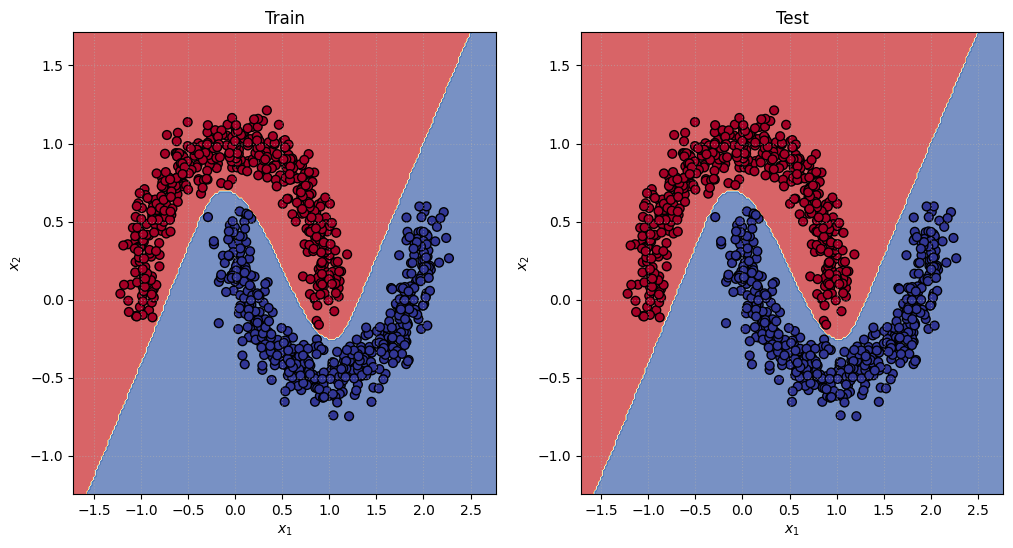

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_moon, X, y)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_moon, X, y)

So that's all about Multi-Layer Perceptron (MLP).